In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
from scipy.signal import welch

In [3]:
load_dotenv()
RISE_TIMES_TYP = os.getenv("PATH_TYP")
RISE_TIMES_MIN = os.getenv("PATH_MIN")
RISE_TIMES_MAX = os.getenv("PATH_MAX")

In [65]:
def get_rise_times(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()
    rise_times = [float(line.strip()) for line in lines]
    return rise_times

def get_periods(rise_times):
    periods = np.diff(rise_times)
    return periods

def get_frequency(periods):
    frequency = np.mean(1 / periods)
    return frequency

def get_TIE(rise_times, frequency):
    time = np.arange(len(rise_times)) / frequency
    ideal_rise_times = rise_times[0] + time
    TIE = rise_times - ideal_rise_times
    return TIE

def get_phi(TIE, frequency):
    phi = TIE * 2 * np.pi * frequency
    centered_phi = phi - np.mean(phi)
    return centered_phi

def get_welch_psd(centered_phi, frequency):
    ss_freqs, ss_psd = welch(centered_phi, fs=frequency, nperseg=len(centered_phi)//2, return_onesided=True, scaling='spectrum')
    return ss_freqs, ss_psd

In [66]:
rise_times = get_rise_times(RISE_TIMES_TYP)
periods = get_periods(rise_times)
frequency = get_frequency(periods)
time = np.arange(len(rise_times)) / frequency
TIE = get_TIE(rise_times, frequency)
phi = get_phi(TIE, frequency)
ss_freqs, ss_psd = get_welch_psd(phi, frequency)

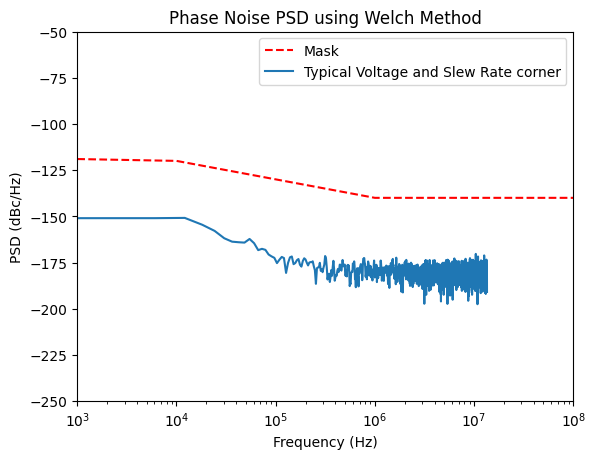

In [67]:
mask = [-119, -120, -130, -140, -140, -140]
mask_f = [1e3, 1e4, 1e5, 1e6, 1e7, 1e8]
plt.plot(mask_f, mask, 'r--', label='Mask')
plt.plot(ss_freqs, 10*np.log10(ss_psd/frequency), label='Typical Voltage and Slew Rate corner')
plt.xscale('log')
plt.xlim([1e3, 1e8])
plt.ylim([-250, -50])
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (dBc/Hz)')
plt.title('Phase Noise PSD using Welch Method')
plt.legend()
plt.show()

In [68]:
ss_freqs_s, ss_psd_s = welch(phi, fs=frequency, nperseg=len(phi)//2, return_onesided=True, scaling='spectrum')
ss_freqs_d, ss_psd_d = welch(phi, fs=frequency, nperseg=len(phi)//2, return_onesided=True, scaling='density')